In [12]:
import numpy as np
import matplotlib.pyplot as plt

# step1 : seed
rng = np.random.default_rng(42)


In [13]:

# step2 : generate datasets
mu_neg = np.array([-3.0, -3.0])
mu_pos = np.array([ 3.0,  3.0])
# dataset A  (cov = I)
Xa_n = rng.multivariate_normal(mu_neg, np.eye(2), 200)
Xa_p = rng.multivariate_normal(mu_pos, np.eye(2), 200)
Xa   = np.vstack([Xa_n, Xa_p])
ya   = np.array([-1]*200 + [1]*200)
print("Dataset A X:", Xa.shape, "y:", ya.shape)
print("  class -1 mean:", Xa_n.mean(0).round(3),
      "  class +1 mean:", Xa_p.mean(0).round(3))

# dataset B  (cov = 3I)
Xb_n = rng.multivariate_normal(mu_neg, 3*np.eye(2), 200)
Xb_p = rng.multivariate_normal(mu_pos, 3*np.eye(2), 200)
Xb   = np.vstack([Xb_n, Xb_p])
yb   = np.array([-1]*200 + [1]*200)
print("Dataset B X:", Xb.shape, "y:", yb.shape)
print("  class -1 std:", Xb_n.std(0).round(3),
      "  class +1 std:", Xb_p.std(0).round(3))



Dataset A X: (400, 2) y: (400,)
  class -1 mean: [-2.978 -3.032]   class +1 mean: [2.937 2.958]
Dataset B X: (400, 2) y: (400,)
  class -1 std: [1.648 1.771]   class +1 std: [1.839 1.8  ]


In [14]:
# step3 : 70-30 split (stratified)
def stratified_split(X, y, train_ratio=0.7, seed=0):
    rg    = np.random.default_rng(seed)
    tr_i, te_i = [], []
    for c in np.unique(y):
        idx  = np.where(y == c)[0]
        rg.shuffle(idx)
        k    = int(len(idx) * train_ratio)
        tr_i.extend(idx[:k].tolist())
        te_i.extend(idx[k:].tolist())
    return (X[tr_i], y[tr_i],
            X[te_i], y[te_i])

Xa_tr, ya_tr, Xa_te, ya_te = stratified_split(Xa, ya)
Xb_tr, yb_tr, Xb_te, yb_te = stratified_split(Xb, yb)
print("A → train:", Xa_tr.shape, ya_tr.shape,
      "test:", Xa_te.shape, ya_te.shape)
print("B → train:", Xb_tr.shape, yb_tr.shape,
      "test:", Xb_te.shape, yb_te.shape)



A → train: (280, 2) (280,) test: (120, 2) (120,)
B → train: (280, 2) (280,) test: (120, 2) (120,)


In [15]:
# step4 : perceptron trainer
def perceptron_train(X, y, eta=0.01, max_ep=300):
    n, d = X.shape
    w    = np.zeros(d)
    b    = 0.0
    print(f"  init w:{w}, b:{b}, shape:{w.shape}")
    misses_per_ep = []
    conv_ep       = None

    for ep in range(max_ep):
        mis = 0
        for i in range(n):
            pred = np.sign(w @ X[i] + b)
            if pred == 0:
                pred = -1.0
            if pred != y[i]:
                w  += eta * y[i] * X[i]
                b  += eta * y[i]
                mis += 1
        misses_per_ep.append(mis)
        if mis == 0 and conv_ep is None:
            conv_ep = ep + 1
            print(f"  converged at epoch {conv_ep}")
            break

    print(f"  final w:{w.round(4)}, b:{b:.4f}")
    print(f"  epochs run: {len(misses_per_ep)}")
    return w, b, misses_per_ep, conv_ep


In [16]:

# step5 : train on A
print("\n=== Dataset A ===")
wa, ba, miss_a, conv_a = perceptron_train(Xa_tr, ya_tr)
acc_a = np.mean(np.sign(wa @ Xa_te.T + ba) == ya_te)
print(f"Test accuracy A: {acc_a:.4f}")
print(f"Convergence epoch A: {conv_a}")




=== Dataset A ===
  init w:[0. 0.], b:0.0, shape:(2,)
  converged at epoch 2
  final w:[0.039  0.0374], b:0.0100
  epochs run: 2
Test accuracy A: 1.0000
Convergence epoch A: 2


In [17]:
# step6 : train on B
print("\n=== Dataset B ===")
wb, bb, miss_b, conv_b = perceptron_train(Xb_tr, yb_tr)
acc_b = np.mean(np.sign(wb @ Xb_te.T + bb) == yb_te)
print(f"Test accuracy B: {acc_b:.4f}")
print(f"Convergence epoch B: {conv_b}")



=== Dataset B ===
  init w:[0. 0.], b:0.0, shape:(2,)


  final w:[0.0547 0.0146], b:0.0100
  epochs run: 300
Test accuracy B: 0.9750
Convergence epoch B: None


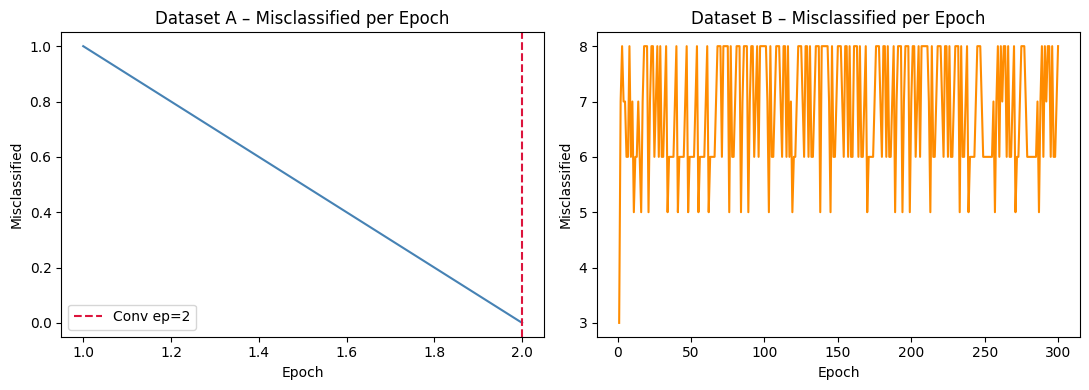

In [18]:

# step7 : plot misclassifications
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, len(miss_a)+1), miss_a, color="steelblue", linewidth=1.5)
axes[0].set_title("Dataset A – Misclassified per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Misclassified")
if conv_a:
    axes[0].axvline(conv_a, color="crimson", linestyle="--",
                    label=f"Conv ep={conv_a}")
    axes[0].legend()

axes[1].plot(range(1, len(miss_b)+1), miss_b, color="darkorange", linewidth=1.5)
axes[1].set_title("Dataset B – Misclassified per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Misclassified")
if conv_b:
    axes[1].axvline(conv_b, color="crimson", linestyle="--",
                    label=f"Conv ep={conv_b}")
    axes[1].legend()
plt.tight_layout()
plt.savefig("q3_misclassified.png", dpi=150)
plt.show()


In [19]:

# step8 : decision boundary helper
def plot_boundary(X_tr, y_tr, X_te, y_te, w, b, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, X, y, split in zip(axes,
                                [X_tr, X_te],
                                [y_tr, y_te],
                                ["Train", "Test"]):
        ax.scatter(X[y==-1, 0], X[y==-1, 1],
                   c="steelblue", s=15, alpha=0.6, label="Class -1")
        ax.scatter(X[y== 1, 0], X[y== 1, 1],
                   c="darkorange", s=15, alpha=0.6, label="Class +1")
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        xs = np.linspace(x_min, x_max, 200)
        if abs(w[1]) > 1e-8:
            ys = -(w[0]*xs + b) / w[1]
            ax.plot(xs, ys, "k-", linewidth=1.5, label="Decision boundary")
        ax.set_title(f"{title} – {split}")
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()



Plotting boundaries for Dataset A


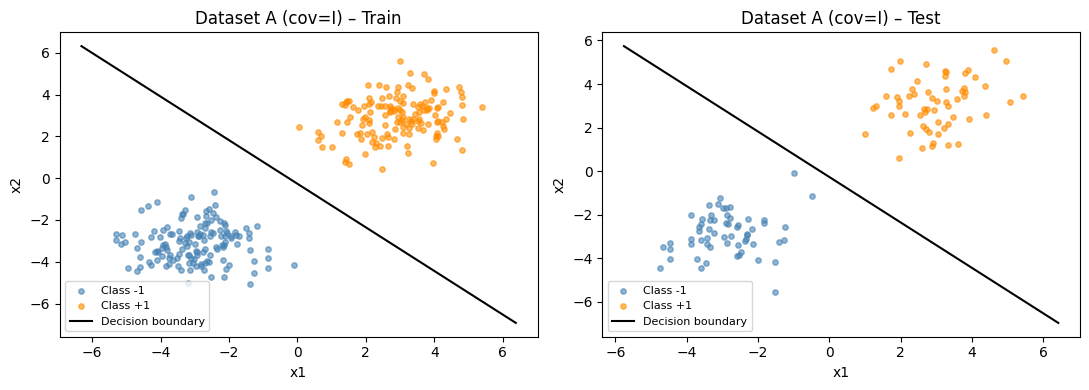

In [20]:

# step9 : boundaries for A
print("\nPlotting boundaries for Dataset A")
plot_boundary(Xa_tr, ya_tr, Xa_te, ya_te,
              wa, ba, "Dataset A (cov=I)", "q3_boundary_A.png")


Plotting boundaries for Dataset B


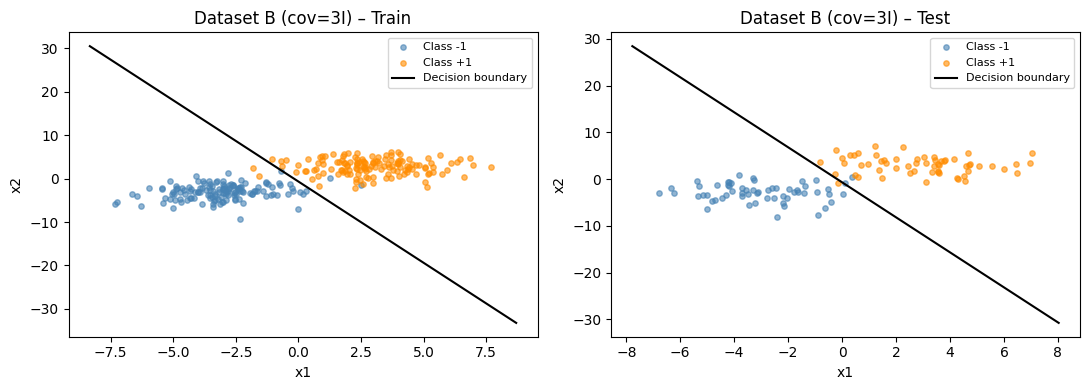

In [21]:

# step10 : boundaries for B
print("Plotting boundaries for Dataset B")
plot_boundary(Xb_tr, yb_tr, Xb_te, yb_te,
              wb, bb, "Dataset B (cov=3I)", "q3_boundary_B.png")



In [22]:
# step11 : summary
print("\n=== Final Summary ===")
print(f"Dataset A | conv_ep={conv_a} | test_acc={acc_a:.4f}")
print(f"Dataset B | conv_ep={conv_b} | test_acc={acc_b:.4f}")
print("w_A:", wa.round(4), "b_A:", round(ba,4))
print("w_B:", wb.round(4), "b_B:", round(bb,4))


=== Final Summary ===
Dataset A | conv_ep=2 | test_acc=1.0000
Dataset B | conv_ep=None | test_acc=0.9750
w_A: [0.039  0.0374] b_A: 0.01
w_B: [0.0547 0.0146] b_B: 0.01
